# Proyek Klasifikasi Gambar: Animals-10
- **Nama:** Rendy Vallentino
- **NIM:** 8030230050

## 1. Import Semua Packages/Library yang Digunakan

In [ ]:
# Install dependencies
!pip install -q tensorflowjs split-folders

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil
import zipfile
import splitfolders

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 83.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 127.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray 2025.12.0 requires packaging>=24.1, but you have packaging 23.2 which is incompatible.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.19.0 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.19

## 2. Data Preparation

### Data Loading

In [ ]:
# Setup Kaggle API
from google.colab import files

# Upload kaggle.json
print("Upload file kaggle.json Anda:")
uploaded = files.upload()

# Configure Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Upload file kaggle.json Anda:


Saving kaggle.json to kaggle.json


In [ ]:
# Download Animals-10 dataset dari Kaggle
!kaggle datasets download -d alessiocorrado99/animals10

# Extract dataset
with zipfile.ZipFile('animals10.zip', 'r') as zip_ref:
    zip_ref.extractall('dataset_raw')

print("Dataset berhasil diextract!")

Dataset URL: https://www.kaggle.com/datasets/alessiocorrado99/animals10
License(s): GPL-2.0
100% 586M/586M [00:33<00:00, 18.1MB/s]

Dataset berhasil diextract!


In [ ]:
import os

raw_dir = 'dataset_raw/raw-img'

# Filter kelas yang diinginkan
target_classes = ['cavallo', 'elefante', 'farfalla', 'gallina', 'gatto']
label_names = {'cavallo': 'kuda', 'elefante': 'gajah', 'farfalla': 'kupu-kupu', 'gallina': 'ayam', 'gatto': 'kucing'}

print(f"Jumlah kelas target: {len(target_classes)}")
print(f"Kelas yang diproses: {[label_names[c] for c in target_classes]}")

# Hitung gambar per kelas target
total_images = 0
print("\nJumlah gambar per kelas:")
for class_name in target_classes:
    class_path = os.path.join(raw_dir, class_name)
    if os.path.isdir(class_path):
        count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        print(f"  {label_names[class_name]} ({class_name}): {count} gambar")
        total_images += count
    else:
        print(f"  ⚠️ Folder {class_name} tidak ditemukan!")

print(f"\nTotal gambar dari kelas target: {total_images}")

Jumlah kelas target: 5
Kelas yang diproses: ['kuda', 'gajah', 'kupu-kupu', 'ayam', 'kucing']

Jumlah gambar per kelas:
  kuda (cavallo): 2623 gambar
  gajah (elefante): 1446 gambar
  kupu-kupu (farfalla): 2112 gambar
  ayam (gallina): 3098 gambar
  kucing (gatto): 1668 gambar

Total gambar dari kelas target: 10947


### Data Preprocessing

#### Rename Label ke Bahasa Indonesia

In [ ]:
import os
import shutil

# Mapping nama kelas dari Bahasa Italia ke Bahasa Indonesia (Hanya 5 kelas target)
target_mapping = {
    'cavallo': 'kuda',
    'elefante': 'gajah',
    'farfalla': 'kupu-kupu',
    'gallina': 'ayam',
    'gatto': 'kucing'
}

raw_dir = 'dataset_raw/raw-img'

print("Mengubah nama folder target ke Bahasa Indonesia...")
for old_name, new_name in target_mapping.items():
    old_path = os.path.join(raw_dir, old_name)
    new_path = os.path.join(raw_dir, new_name)
    if os.path.exists(old_path):
        os.rename(old_path, new_path)
        print(f"  {old_name} -> {new_name} ✅")
    elif os.path.exists(new_path):
        print(f"  {new_name} (sudah tersedia) ✅")

# Menghapus folder yang tidak digunakan agar tidak ikut masuk ke model
print("\nMembersihkan folder kelas yang tidak digunakan...")
if os.path.exists(raw_dir):
    all_folders = os.listdir(raw_dir)
    for folder in all_folders:
        if folder not in target_mapping.values() and folder not in target_mapping.keys():
            folder_path = os.path.join(raw_dir, folder)
            if os.path.isdir(folder_path):
                shutil.rmtree(folder_path)
                print(f"  {folder} dihapus 🗑️")

# Verifikasi akhir
if os.path.exists(raw_dir):
    classes = sorted(os.listdir(raw_dir))
    print(f"\nKelas Final yang digunakan: {classes}")

Mengubah nama folder target ke Bahasa Indonesia...
  cavallo -> kuda ✅
  elefante -> gajah ✅
  farfalla -> kupu-kupu ✅
  gallina -> ayam ✅
  gatto -> kucing ✅

Membersihkan folder kelas yang tidak digunakan...
  ragno dihapus 🗑️
  pecora dihapus 🗑️
  mucca dihapus 🗑️
  cane dihapus 🗑️
  scoiattolo dihapus 🗑️

Kelas Final yang digunakan: ['ayam', 'gajah', 'kucing', 'kuda', 'kupu-kupu']


#### Split Dataset

In [ ]:
# >>Dataset dibagi dengan proposi 700% untuk training, 15% untuk Validation, dan 15% untuk Testing.
# Alasan logisnya adalah total dataset Animals-10 yang digunakan (setelah difilter menjadi 5 kelas)
# berjumlah besar (sekitar 10.000+ gambar).
# Proporsi 70% sudah sangat cukup bagi model untuk belajar mengekstraksi fitur tanpa kekurangan data,
# sementara prosi 15% (sekitar 1.600+ gambar) cukup representaatif untuk melakukan validasi dan pengujian yang valid.

# Split dataset menjadi train, validation, dan test (70%, 15%, 15%)
input_folder = 'dataset_raw/raw-img'
output_folder = 'dataset'

# Hapus folder output jika sudah ada
if os.path.exists(output_folder):
    shutil.rmtree(output_folder)

# Split dataset
splitfolders.ratio(
    input_folder,
    output=output_folder,
    seed=42,
    ratio=(0.7, 0.15, 0.15),  # train, val, test
    group_prefix=None
)

print("Dataset berhasil di-split!")
print(f"Train: 70%, Validation: 15%, Test: 15%")

Copying files: 10947 files [00:02, 4186.09 files/s]

Dataset berhasil di-split!
Train: 70%, Validation: 15%, Test: 15%


In [ ]:
# Verifikasi hasil split
train_dir = 'dataset/train'
val_dir = 'dataset/val'
test_dir = 'dataset/test'

def count_images(directory):
    total = 0
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            total += count
    return total

train_count = count_images(train_dir)
val_count = count_images(val_dir)
test_count = count_images(test_dir)

print(f"Training set: {train_count} gambar")
print(f"Validation set: {val_count} gambar")
print(f"Test set: {test_count} gambar")
print(f"Total: {train_count + val_count + test_count} gambar")

Training set: 7661 gambar
Validation set: 1639 gambar
Test set: 1647 gambar
Total: 10947 gambar


In [ ]:
# Konfigurasi
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data Augmentation untuk training (moderate)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Hanya rescale untuk validation dan test
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Load data (Otomatis mendeteksi folder yang tersisa: kuda, gajah, kupu-kupu, ayam, kucing)
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Simpan class names
class_names = sorted(list(train_generator.class_indices.keys()))
num_classes = len(class_names)
print(f"\nJumlah kelas terdeteksi: {num_classes}")
print(f"Nama kelas: {class_names}")

Found 7661 images belonging to 5 classes.
Found 1639 images belonging to 5 classes.
Found 1647 images belonging to 5 classes.

Jumlah kelas terdeteksi: 5
Nama kelas: ['ayam', 'gajah', 'kucing', 'kuda', 'kupu-kupu']


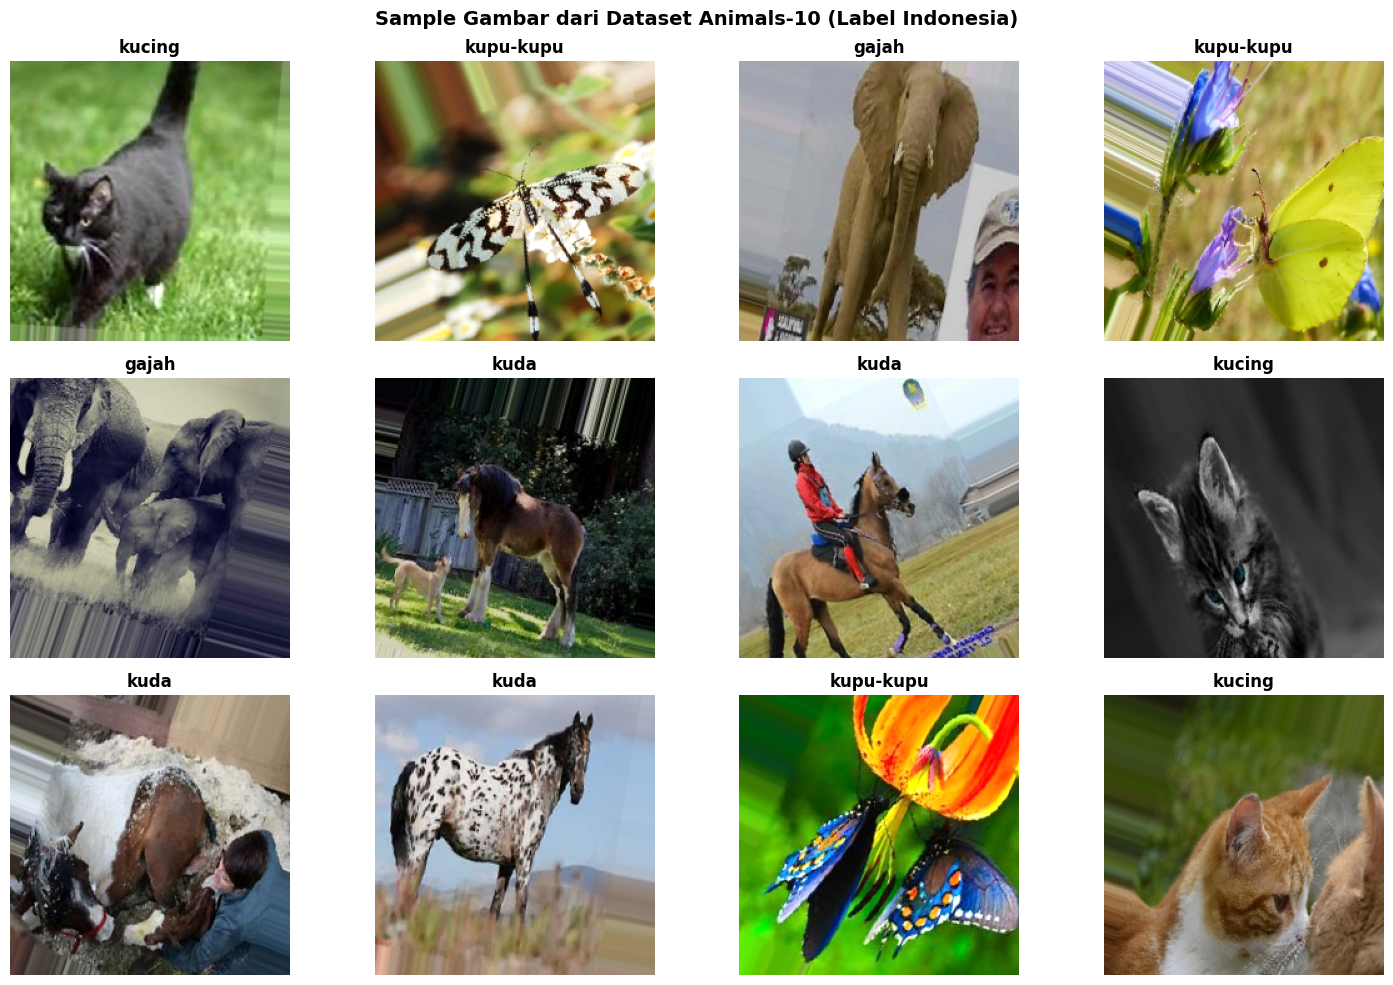

In [ ]:
# Visualisasi sample gambar dari dataset
plt.figure(figsize=(15, 10))

# Ambil satu batch dari training data
images, labels = next(train_generator)

for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.imshow(images[i])
    label_idx = np.argmax(labels[i])
    plt.title(class_names[label_idx], fontsize=12, fontweight='bold')
    plt.axis('off')

plt.suptitle('Sample Gambar dari Dataset Animals-10 (Label Indonesia)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Membangun Model (CNN From Scratch)

In [ ]:
# Membangun Model CNN Sequential yang lebih dalam
model = Sequential([
    # Block 1
    Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(224, 224, 3)),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Block 2
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Block 3
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Block 4
    Conv2D(512, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(512, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Global Average Pooling (lebih efisien dari Flatten)
    GlobalAveragePooling2D(),

    # Fully Connected Layers
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Summary model
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 5,091,397 (19.42 MB)

 Trainable params: 5,086,021 (19.40 MB)

 Non-trainable params: 5,376 (21.00 KB)

## Training Model CNN (From Scratch)

**EarlyStopping:** Mencegah model mengalami overfitting dan menghemat waktu komputasi dengan cara menghentikan proses training secara otomatis jika akurasi validasi tidak lagi mengalami peningkatan setelah beberapa epoch.

**ModelCheckpoint:** Berfungsi untuk menyimpan secara otomatis bobot (weights) model yang memiliki performa paling baik selama proses training berlangsung.

**ReduceLROnPlateau:** Membantu model untuk menemukan titik optimal yang lebih presisi dengan cara menurunkan nilai learning rate ketika kurva metrik (seperti loss) mulai stagnan (mendatar).

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

# Training
EPOCHS = 50

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 792ms/step - accuracy: 0.3580 - loss: 1.8480
Epoch 1: val_accuracy improved from None to 0.25076, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
240/240 ━━━━━━━━━━━━━━━━━━━━ 276s 921ms/step - accuracy: 0.3988 - loss: 1.6374 - val_accuracy: 0.2508 - val_loss: 1.9166 - learning_rate: 0.0010
Epoch 2/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 655ms/step - accuracy: 0.5028 - loss: 1.3058
Epoch 2: val_accuracy improved from 0.25076 to 0.33984, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
240/240 ━━━━━━━━━━━━━━━━━━━━ 166s 690ms/step - accuracy: 0.5212 - loss: 1.2663 - val_accuracy: 0.3398 - val_loss: 1.6868 - learning_rate: 0.0010
Epoch 3/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 660ms/step - accuracy: 0.5713 - loss: 1.1374
Epoch 3: val_accuracy improved from 0.33984 to 0.58511, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
240/240 ━━━━━━━━━━━━━━━━━━

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Evaluasi dan Visualisasi

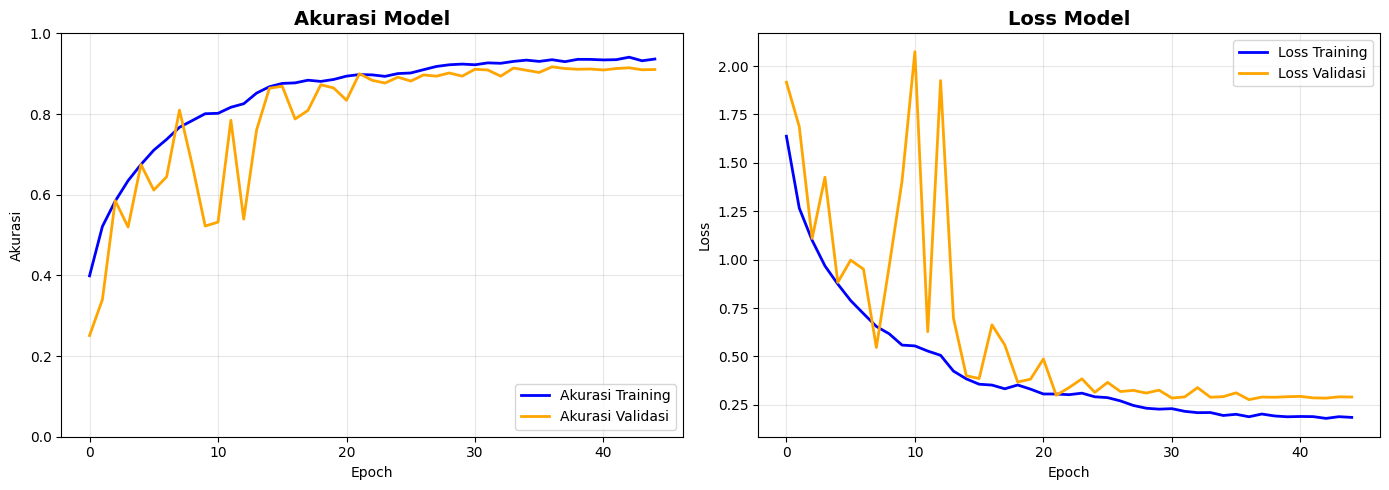

Plot disimpan sebagai 'training_history.png'


In [ ]:
# Plot Akurasi dan Loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Akurasi

axes[0].plot(history.history['accuracy'], label='Akurasi Training', color='blue', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Akurasi Validasi', color='orange', linewidth=2)
axes[0].set_title('Akurasi Model', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Akurasi')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1])

# Plot Loss
axes[1].plot(history.history['loss'], label='Loss Training', color='blue', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Loss Validasi', color='orange', linewidth=2)
axes[1].set_title('Loss Model', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

print("Plot disimpan sebagai 'training_history.png'")

In [ ]:
# Evaluasi pada Training Set (tanpa augmentasi)
train_eval_generator = val_test_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

train_loss, train_accuracy = model.evaluate(train_eval_generator, verbose=1)
print(f"\n{'='*50}")
print(f"Training Set Accuracy: {train_accuracy*100:.2f}%")
print(f"Training Set Loss: {train_loss:.4f}")

# Evaluasi pada Test Set
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)
print(f"\n{'='*50}")
print(f"Test Set Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Set Loss: {test_loss:.4f}")
print(f"{'='*50}")

# Verifikasi kriteria
print(f"\n{'='*50}")
print("VERIFIKASI KRITERIA:")
print(f"{'='*50}")
if train_accuracy >= 0.85:
    print(f"✅ Training Accuracy >= 85%: PASSED ({train_accuracy*100:.2f}%)")
else:
    print(f"❌ Training Accuracy >= 85%: FAILED ({train_accuracy*100:.2f}%)")

if test_accuracy >= 0.85:
    print(f"✅ Test Accuracy >= 85%: PASSED ({test_accuracy*100:.2f}%)")
else:
    print(f"❌ Test Accuracy >= 85%: FAILED ({test_accuracy*100:.2f}%)")

Found 7661 images belonging to 5 classes.
240/240 ━━━━━━━━━━━━━━━━━━━━ 49s 203ms/step - accuracy: 0.9475 - loss: 0.1531

Training Set Accuracy: 94.75%
Training Set Loss: 0.1531
52/52 ━━━━━━━━━━━━━━━━━━━━ 18s 354ms/step - accuracy: 0.9041 - loss: 0.2880

Test Set Accuracy: 90.41%
Test Set Loss: 0.2880

VERIFIKASI KRITERIA:
✅ Training Accuracy >= 85%: PASSED (94.75%)
✅ Test Accuracy >= 85%: PASSED (90.41%)


## Transfer Learning dengan MobileNetV2

Sekarang kita akan mencoba menggunakan arsitektur pre-trained MobileNetV2 untuk melihat apakah performa model dapat ditingkatkan lebih jauh.

In [ ]:
from tensorflow.keras.applications import MobileNetV2

# 1. Load base model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# 2. Freeze base model
base_model.trainable = False

# 3. Bangun model di atas base model
mobilenet_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

# 4. Compile
mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,229 (9.87 MB)

 Trainable params: 329,733 (1.26 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

### Training MobileNetV2

In [ ]:
callbacks_mobilenet = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_mobilenet_model.keras', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
]

history_mobilenet = mobilenet_model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    callbacks=callbacks_mobilenet
)

Epoch 1/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 173s 636ms/step - accuracy: 0.9419 - loss: 0.1860 - val_accuracy: 0.9756 - val_loss: 0.0818 - learning_rate: 0.0010
Epoch 2/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 119s 497ms/step - accuracy: 0.9648 - loss: 0.1067 - val_accuracy: 0.9725 - val_loss: 0.0800 - learning_rate: 0.0010
Epoch 3/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 120s 500ms/step - accuracy: 0.9706 - loss: 0.0885 - val_accuracy: 0.9750 - val_loss: 0.0717 - learning_rate: 0.0010
Epoch 4/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 122s 506ms/step - accuracy: 0.9708 - loss: 0.0847 - val_accuracy: 0.9756 - val_loss: 0.0717 - learning_rate: 0.0010
Epoch 5/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 121s 505ms/step - accuracy: 0.9726 - loss: 0.0777 - val_accuracy: 0.9768 - val_loss: 0.0711 - learning_rate: 0.0010
Epoch 6/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 121s 505ms/step - accuracy: 0.9752 - loss: 0.0745 - val_accuracy: 0.9756 - val_loss: 0.0755 - learning_rate: 0.0010
Epoch 7/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 121s 504ms/step - accura

In [ ]:
# Evaluasi MobileNetV2 pada Test Set
test_loss_mn, test_acc_mn = mobilenet_model.evaluate(test_generator)
print(f"\nTest Accuracy (MobileNetV2): {test_acc_mn*100:.2f}%")

52/52 ━━━━━━━━━━━━━━━━━━━━ 17s 340ms/step - accuracy: 0.9854 - loss: 0.0530

Test Accuracy (MobileNetV2): 98.54%


### Visualisasi Training MobileNetV2

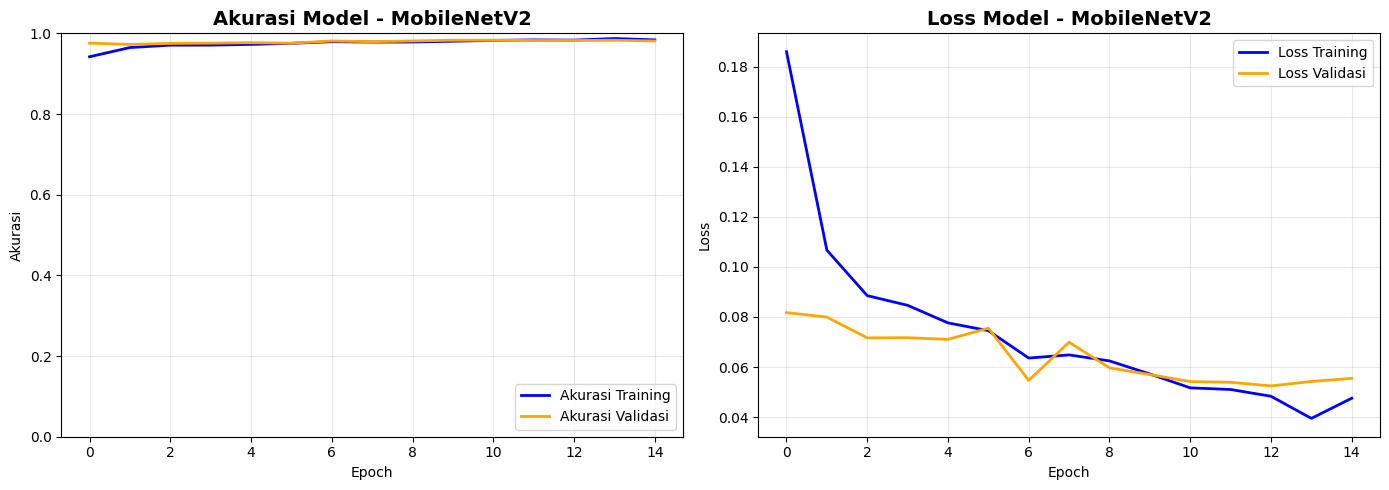

In [19]:
# Plot Akurasi dan Loss - MobileNetV2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_mobilenet.history['accuracy'], label='Akurasi Training', color='blue', linewidth=2)
axes[0].plot(history_mobilenet.history['val_accuracy'], label='Akurasi Validasi', color='orange', linewidth=2)
axes[0].set_title('Akurasi Model - MobileNetV2', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Akurasi')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1])

axes[1].plot(history_mobilenet.history['loss'], label='Loss Training', color='blue', linewidth=2)
axes[1].plot(history_mobilenet.history['val_loss'], label='Loss Validasi', color='orange', linewidth=2)
axes[1].set_title('Loss Model - MobileNetV2', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

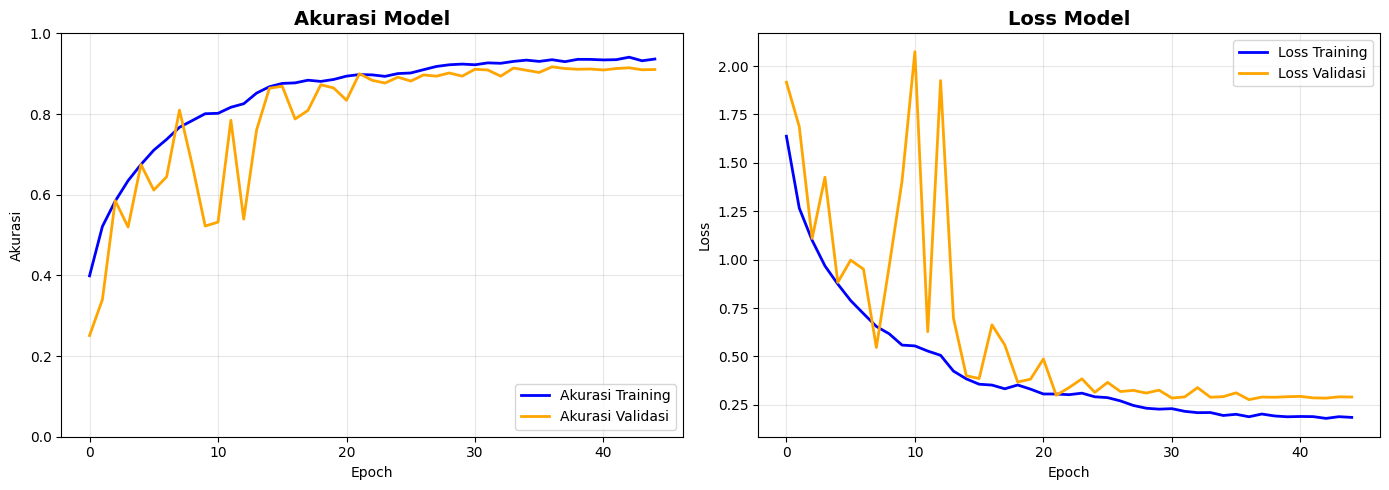

Plot disimpan sebagai 'training_history.png'


In [20]:
# Plot Akurasi dan Loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Akurasi

axes[0].plot(history.history['accuracy'], label='Akurasi Training', color='blue', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Akurasi Validasi', color='orange', linewidth=2)
axes[0].set_title('Akurasi Model', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Akurasi')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1])

# Plot Loss
axes[1].plot(history.history['loss'], label='Loss Training', color='blue', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Loss Validasi', color='orange', linewidth=2)
axes[1].set_title('Loss Model', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

print("Plot disimpan sebagai 'training_history.png'")

In [21]:
# Evaluasi pada Training Set (tanpa augmentasi)
train_eval_generator = val_test_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

train_loss, train_accuracy = model.evaluate(train_eval_generator, verbose=1)
print(f"\n{'='*50}")
print(f"Training Set Accuracy: {train_accuracy*100:.2f}%")
print(f"Training Set Loss: {train_loss:.4f}")

# Evaluasi pada Test Set
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)
print(f"\n{'='*50}")
print(f"Test Set Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Set Loss: {test_loss:.4f}")
print(f"{'='*50}")

# Verifikasi kriteria
print(f"\n{'='*50}")
print("VERIFIKASI KRITERIA:")
print(f"{'='*50}")
if train_accuracy >= 0.85:
    print(f"✅ Training Accuracy >= 85%: PASSED ({train_accuracy*100:.2f}%)")
else:
    print(f"❌ Training Accuracy >= 85%: FAILED ({train_accuracy*100:.2f}%)")

if test_accuracy >= 0.85:
    print(f"✅ Test Accuracy >= 85%: PASSED ({test_accuracy*100:.2f}%)")
else:
    print(f"❌ Test Accuracy >= 85%: FAILED ({test_accuracy*100:.2f}%)")

Found 7661 images belonging to 5 classes.
240/240 ━━━━━━━━━━━━━━━━━━━━ 40s 165ms/step - accuracy: 0.9475 - loss: 0.1531

Training Set Accuracy: 94.75%
Training Set Loss: 0.1531
52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 234ms/step - accuracy: 0.9041 - loss: 0.2880

Test Set Accuracy: 90.41%
Test Set Loss: 0.2880

VERIFIKASI KRITERIA:
✅ Training Accuracy >= 85%: PASSED (94.75%)
✅ Test Accuracy >= 85%: PASSED (90.41%)


## Evaluasi Akhir & Confusion Matrix


  EVALUASI: CNN From Scratch
              precision    recall  f1-score   support

        ayam       0.95      0.91      0.93       466
       gajah       0.73      0.95      0.82       218
      kucing       0.91      0.86      0.89       251
        kuda       0.93      0.86      0.90       394
   kupu-kupu       0.97      0.94      0.95       318

    accuracy                           0.90      1647
   macro avg       0.90      0.91      0.90      1647
weighted avg       0.91      0.90      0.91      1647



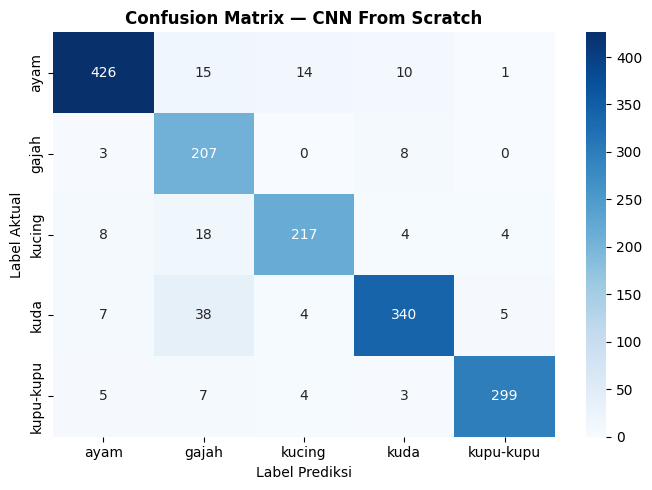


  EVALUASI: MobileNetV2
              precision    recall  f1-score   support

        ayam       0.99      0.99      0.99       466
       gajah       0.96      0.98      0.97       218
      kucing       0.99      0.99      0.99       251
        kuda       0.99      0.97      0.98       394
   kupu-kupu       0.99      0.99      0.99       318

    accuracy                           0.99      1647
   macro avg       0.98      0.99      0.98      1647
weighted avg       0.99      0.99      0.99      1647



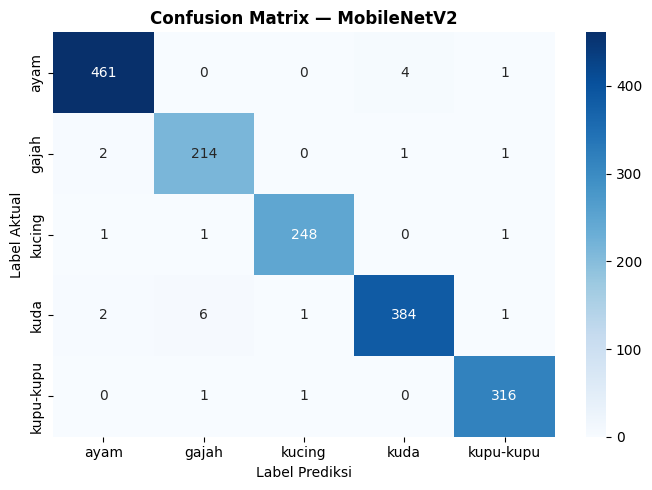

In [22]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Reset generator agar prediksi dari awal
test_generator.reset()

for nama_model, mdl in [("CNN From Scratch", model), ("MobileNetV2", mobilenet_model)]:
    print(f"\n{'='*55}")
    print(f"  EVALUASI: {nama_model}")
    print(f"{'='*55}")

    test_generator.reset()
    y_pred_prob = mdl.predict(test_generator, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = test_generator.classes

    # Classification Report
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {nama_model}', fontweight='bold')
    plt.ylabel('Label Aktual')
    plt.xlabel('Label Prediksi')
    plt.tight_layout()
    plt.show()


jika grafik Train Accuracy dan Validation Accuracy berdekatan dan terus naik di atas 85%, sebutkan bahwa model sudah Good Fit. Namun jika Train Accuracy sangat tinggi (mendekati 100%) sedangkan Validation Accuracy tertahan di bawah 80%, sebutkan bahwa model mengalami Overfitting dan jelaskan pada model mana hal itu terjadi.

## Konversi Model

In [23]:
# 1. Simpan sebagai SavedModel
saved_model_path = 'saved_model'
model.export(saved_model_path)
print(f"✅ Model disimpan dalam format SavedModel di: {saved_model_path}/")

# Verifikasi SavedModel
# Note: model.export() creates a SavedModel directory, not a single file.
# To load it, we use tf.keras.models.load_model with the directory path.
loaded_model = keras.layers.TFSMLayer(saved_model_path, call_endpoint='serve')
print(f"   SavedModel berhasil di-load sebagai TFSMLayer.")

Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  140028692102800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140028692102224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140028692102416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140028688581456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140028692101456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140028692102032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140028688582032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140028688582224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140028688581264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140028688583376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140028688583184: Te

In [24]:
# 2. Konversi ke TensorFlow Lite
tflite_model_path = 'model.tflite'

# Konversi
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_path)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

# Simpan
with open(tflite_model_path, 'wb') as f:
    f.write(tflite_model)

# Verifikasi ukuran file
tflite_size = os.path.getsize(tflite_model_path) / (1024 * 1024)
print(f"✅ Model disimpan dalam format TF-Lite: {tflite_model_path}")
print(f"   Ukuran file: {tflite_size:.2f} MB")

✅ Model disimpan dalam format TF-Lite: model.tflite
   Ukuran file: 4.91 MB


In [25]:
# 3. Konversi ke TensorFlow.js
tfjs_model_path = 'tfjs_model'

!tensorflowjs_converter --input_format=tf_saved_model --output_format=tfjs_graph_model {saved_model_path} {tfjs_model_path}

print(f"\n✅ Model disimpan dalam format TFJS di: {tfjs_model_path}/")

# List file TFJS
print("   Files:")
for f in os.listdir(tfjs_model_path):
    size = os.path.getsize(os.path.join(tfjs_model_path, f)) / 1024
    print(f"   - {f} ({size:.2f} KB)")

2026-07-18 10:36:48.177381: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1784371008.200947   52773 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784371008.208409   52773 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1784371008.228231   52773 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784371008.228274   52773 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784371008.228279   52773 computation_placer.cc:177] computation placer alr

In [26]:
# Verifikasi semua format tersimpan
print("="*60)
print("VERIFIKASI SEMUA FORMAT MODEL")
print("="*60)

# SavedModel
if os.path.exists(saved_model_path) and os.path.isdir(saved_model_path):
    print(f"✅ SavedModel: {saved_model_path}/")
else:
    print(f"❌ SavedModel tidak ditemukan")

# TF-Lite
if os.path.exists(tflite_model_path):
    print(f"✅ TF-Lite: {tflite_model_path} ({os.path.getsize(tflite_model_path)/(1024*1024):.2f} MB)")
else:
    print(f"❌ TF-Lite tidak ditemukan")

# TFJS
if os.path.exists(tfjs_model_path) and os.path.isdir(tfjs_model_path):
    print(f"✅ TFJS: {tfjs_model_path}/")
else:
    print(f"❌ TFJS tidak ditemukan")

print("="*60)

VERIFIKASI SEMUA FORMAT MODEL
✅ SavedModel: saved_model/
✅ TF-Lite: model.tflite (4.91 MB)
✅ TFJS: tfjs_model/


## Inferensi Model / Uji Coba Model

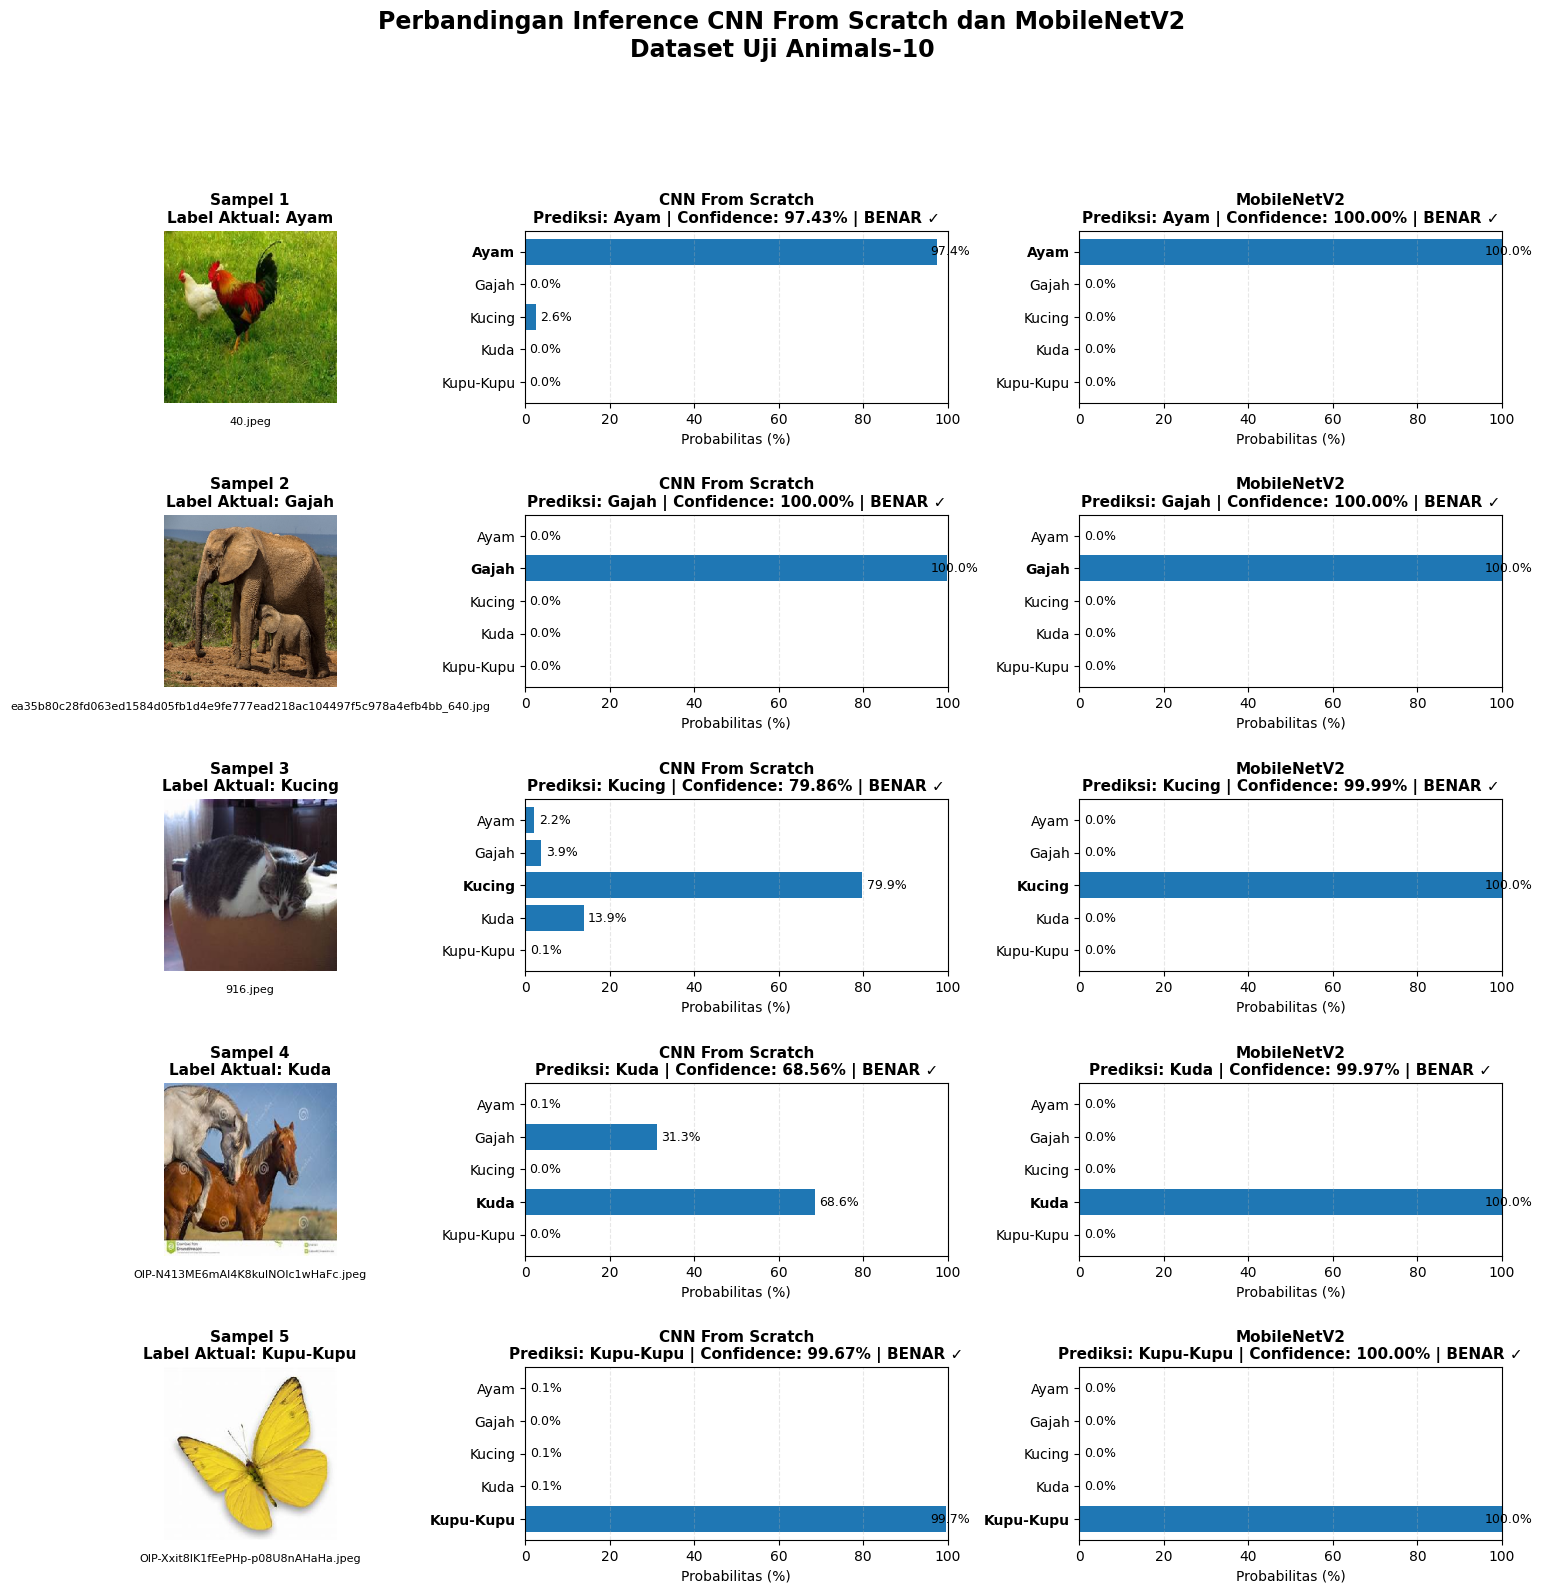


RINGKASAN PERBANDINGAN INFERENCE


,Nama File,Label Aktual,Prediksi CNN,Confidence CNN (%),CNN Benar,Prediksi MobileNetV2,Confidence MobileNetV2 (%),MobileNetV2 Benar
0,40.jpeg,Ayam,Ayam,97.43,Ya,Ayam,100.00,Ya
1,ea35b80c28fd063ed1584d05fb1d4e9fe777ead218ac10...,Gajah,Gajah,100.00,Ya,Gajah,100.00,Ya
2,916.jpeg,Kucing,Kucing,79.86,Ya,Kucing,99.99,Ya
3,OIP-N413ME6mAl4K8kulNOIc1wHaFc.jpeg,Kuda,Kuda,68.56,Ya,Kuda,99.97,Ya
4,OIP-Xxit8lK1fEePHp-p08U8nAHaHa.jpeg,Kupu-Kupu,Kupu-Kupu,99.67,Ya,Kupu-Kupu,100.00,Ya



CNN From Scratch benar pada 5/5 sampel yang ditampilkan.
MobileNetV2 benar pada 5/5 sampel yang ditampilkan.

Catatan: hasil di atas merupakan demonstrasi inference pada sampel terpilih. Akurasi resmi tetap harus menggunakan evaluasi seluruh test set.


In [28]:
# ============================================================
# PERBANDINGAN INFERENCE: CNN FROM SCRATCH vs MobileNetV2
# Menampilkan satu sampel dari setiap kelas dengan:
# 1. Gambar asli
# 2. Distribusi probabilitas CNN
# 3. Distribusi probabilitas MobileNetV2
# 4. Tabel ringkasan prediksi
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Ekstensi gambar yang didukung
VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def prepare_image(img_path):
    """
    Memuat dan menyiapkan satu gambar agar sesuai dengan preprocessing
    yang digunakan saat training CNN dan MobileNetV2.

    Catatan:
    Notebook ini melatih kedua model dengan normalisasi 1/255,
    sehingga preprocessing inference juga menggunakan skala yang sama.
    """
    display_img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(display_img).astype(np.float32)
    img_array = np.expand_dims(img_array, axis=0) / 255.0
    return display_img, img_array


def predict_probabilities(img_array, trained_model):
    """Menghasilkan probabilitas, kelas prediksi, dan confidence."""
    probabilities = trained_model.predict(img_array, verbose=0)[0]
    predicted_index = int(np.argmax(probabilities))
    predicted_class = class_names[predicted_index]
    confidence = float(probabilities[predicted_index] * 100)
    return probabilities, predicted_class, confidence


def select_test_samples(test_directory, labels, samples_per_class=1, seed=42):
    """
    Memilih sampel secara reproducible dari setiap kelas.
    Berbeda dari os.listdir() biasa, urutan kelas dan gambar dibuat stabil.
    """
    rng = np.random.default_rng(seed)
    selected = []

    for label in labels:
        class_dir = Path(test_directory) / label
        image_files = sorted([
            path for path in class_dir.iterdir()
            if path.is_file() and path.suffix.lower() in VALID_EXTENSIONS
        ])

        if not image_files:
            print(f"⚠ Tidak ditemukan gambar pada kelas: {label}")
            continue

        number_to_select = min(samples_per_class, len(image_files))
        selected_indices = rng.choice(
            len(image_files),
            size=number_to_select,
            replace=False
        )

        for index in np.atleast_1d(selected_indices):
            selected.append((label, image_files[int(index)]))

    return selected


def plot_probability_distribution(
    axis,
    probabilities,
    predicted_class,
    actual_class,
    model_name
):
    """Membuat grafik probabilitas horizontal untuk satu model."""
    probabilities_percent = probabilities * 100
    y_positions = np.arange(len(class_names))

    bars = axis.barh(y_positions, probabilities_percent)
    axis.set_yticks(y_positions)
    axis.set_yticklabels([name.title() for name in class_names])
    axis.invert_yaxis()
    axis.set_xlim(0, 100)
    axis.set_xlabel("Probabilitas (%)")
    axis.grid(axis="x", linestyle="--", alpha=0.30)

    is_correct = predicted_class == actual_class
    status = "BENAR ✓" if is_correct else "SALAH ✗"
    confidence = np.max(probabilities_percent)

    axis.set_title(
        f"{model_name}\n"
        f"Prediksi: {predicted_class.title()} | "
        f"Confidence: {confidence:.2f}% | {status}",
        fontsize=11,
        fontweight="bold"
    )

    # Tampilkan nilai probabilitas pada setiap batang.
    for bar, value in zip(bars, probabilities_percent):
        text_x = min(value + 1.0, 96.0)
        axis.text(
            text_x,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.1f}%",
            va="center",
            fontsize=9
        )

    # Tandai kelas aktual dengan teks tambahan.
    actual_index = class_names.index(actual_class)
    axis.get_yticklabels()[actual_index].set_fontweight("bold")


# Pilih satu gambar dari masing-masing kelas.
# Ubah samples_per_class menjadi 2 jika ingin menampilkan dua sampel per kelas.
test_samples = select_test_samples(
    test_directory=test_dir,
    labels=class_names,
    samples_per_class=1,
    seed=42
)

if not test_samples:
    raise ValueError("Tidak ada gambar uji yang ditemukan.")

# Simpan hasil untuk tabel ringkasan.
comparison_results = []

# Satu baris untuk setiap gambar:
# kolom 1 = gambar asli, kolom 2 = probabilitas CNN,
# kolom 3 = probabilitas MobileNetV2.
number_of_samples = len(test_samples)
figure = plt.figure(figsize=(18, 3.4 * number_of_samples))
grid = figure.add_gridspec(
    nrows=number_of_samples,
    ncols=3,
    width_ratios=[1.05, 1.55, 1.55],
    hspace=0.65,
    wspace=0.35
)

for row_index, (actual_class, img_path) in enumerate(test_samples):
    display_img, img_array = prepare_image(img_path)

    cnn_prob, cnn_pred, cnn_conf = predict_probabilities(
        img_array,
        model
    )
    mn_prob, mn_pred, mn_conf = predict_probabilities(
        img_array,
        mobilenet_model
    )

    # Kolom gambar asli
    image_axis = figure.add_subplot(grid[row_index, 0])
    image_axis.imshow(display_img)
    image_axis.axis("off")
    image_axis.set_title(
        f"Sampel {row_index + 1}\n"
        f"Label Aktual: {actual_class.title()}",
        fontsize=11,
        fontweight="bold"
    )
    image_axis.text(
        0.5,
        -0.08,
        img_path.name,
        transform=image_axis.transAxes,
        ha="center",
        va="top",
        fontsize=8
    )

    # Kolom hasil CNN
    cnn_axis = figure.add_subplot(grid[row_index, 1])
    plot_probability_distribution(
        cnn_axis,
        cnn_prob,
        cnn_pred,
        actual_class,
        "CNN From Scratch"
    )

    # Kolom hasil MobileNetV2
    mn_axis = figure.add_subplot(grid[row_index, 2])
    plot_probability_distribution(
        mn_axis,
        mn_prob,
        mn_pred,
        actual_class,
        "MobileNetV2"
    )

    comparison_results.append({
        "Nama File": img_path.name,
        "Label Aktual": actual_class.title(),
        "Prediksi CNN": cnn_pred.title(),
        "Confidence CNN (%)": round(cnn_conf, 2),
        "CNN Benar": "Ya" if cnn_pred == actual_class else "Tidak",
        "Prediksi MobileNetV2": mn_pred.title(),
        "Confidence MobileNetV2 (%)": round(mn_conf, 2),
        "MobileNetV2 Benar": "Ya" if mn_pred == actual_class else "Tidak"
    })

figure.suptitle(
    "Perbandingan Inference CNN From Scratch dan MobileNetV2\n"
    "Dataset Uji Animals-10",
    fontsize=17,
    fontweight="bold",
    y=1.01
)

plt.show()

# Tabel ringkasan hasil inference.
comparison_df = pd.DataFrame(comparison_results)

print("\n" + "=" * 90)
print("RINGKASAN PERBANDINGAN INFERENCE")
print("=" * 90)
display(comparison_df)

# Ringkasan hanya berlaku untuk sampel yang ditampilkan,
# bukan pengganti hasil evaluasi seluruh test set.
cnn_sample_correct = (comparison_df["CNN Benar"] == "Ya").sum()
mn_sample_correct = (comparison_df["MobileNetV2 Benar"] == "Ya").sum()

print(
    f"\nCNN From Scratch benar pada "
    f"{cnn_sample_correct}/{len(comparison_df)} sampel yang ditampilkan."
)
print(
    f"MobileNetV2 benar pada "
    f"{mn_sample_correct}/{len(comparison_df)} sampel yang ditampilkan."
)
print(
    "\nCatatan: hasil di atas merupakan demonstrasi inference pada sampel terpilih. "
    "Akurasi resmi tetap harus menggunakan evaluasi seluruh test set."
)

In [36]:
# TF-Lite Inference Test
print("Testing TF-Lite Model...")

# Load TFLite model
interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Test dengan gambar pertama
if test_samples:
    # Use the image path from the first sample in test_samples
    img_path_for_tflite = test_samples[0][1]
    img = image.load_img(img_path_for_tflite, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0).astype(np.float32)
    img_array = img_array / 255.0

    interpreter.set_tensor(input_details[0]['index'], img_array)
    interpreter.invoke()

    tflite_predictions = interpreter.get_tensor(output_details[0]['index'])
    tflite_predicted_class = class_names[np.argmax(tflite_predictions[0])]
    tflite_confidence = np.max(tflite_predictions[0]) * 100

    print(f"✅ TF-Lite Prediction: {tflite_predicted_class} ({tflite_confidence:.1f} %)")
    print(f"   TF-Lite model berfungsi dengan baik!")
else:
    print("Tidak ada gambar sampel yang tersedia untuk pengujian TF-Lite model.")

Testing TF-Lite Model...
✅ TF-Lite Prediction: ayam (97.3 %)
   TF-Lite model berfungsi dengan baik!


In [33]:
# Download semua model
from google.colab import files
import shutil

# Zip semua model
print("Membuat archive untuk download...")

# Zip SavedModels
shutil.make_archive('saved_model', 'zip', '.', 'saved_model')
print("✅ saved_model.zip created")

# Zip TFJS
shutil.make_archive('tfjs_model', 'zip', '.', 'tfjs_model')
print("✅ tfjs_model.zip created")

# Buat requirements.txt
print("\nMembuat requirements.txt...")
requirements = [
    'tensorflow==2.19.0',
    'tensorflowjs',
    'split-folders',
    'numpy',
    'matplotlib'
]
with open('requirements.txt', 'w') as f:
    for req in requirements:
        f.write(req + '\n')
print("✅ requirements.txt created")

print("\n" + "="*50)
print("Files ready for download:")
print("- saved_model.zip")
print("- model.tflite")
print("- tfjs_model.zip")
print("- requirements.txt")
print("="*50)

# Uncomment untuk auto-download
files.download('saved_model.zip')
files.download('model.tflite')
files.download('tfjs_model.zip')
files.download('requirements.txt')


Membuat archive untuk download...
✅ saved_model.zip created
✅ tfjs_model.zip created

Membuat requirements.txt...
✅ requirements.txt created

Files ready for download:
- saved_model.zip
- model.tflite
- tfjs_model.zip
- requirements.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>